In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

import joblib

In [51]:
dataset=pd.read_excel('/home/rgukt123/Flood-Prediction-System/Dataset/flood dataset.xlsx')

In [53]:
print(dataset.shape)

(10000, 9)


In [54]:
print(dataset.head())

        Temp   Humidity      ANNUAL    Jan-Feb    Mar-May     Jun-Sep  \
0  34.144337  43.912963  218.999493  17.519959  48.179889  120.449721   
1  28.778774  27.585422   55.353599   4.428288  12.177792   30.444479   
2  43.934956  30.108738  103.991908   8.319353  22.878220   57.195550   
3  21.569354  34.453690  198.984191  15.918735  43.776522  109.441305   
4  32.635692  36.292267  144.626803  11.570144  31.817897   79.544742   

     Oct-Dec    avgjune  flood  
0  32.849924  30.112430      1  
1   8.303040   7.611120      0  
2  15.598786  14.298887      1  
3  29.847629  27.360326      0  
4  21.694021  19.886185      0  


In [55]:
print("Dataset Shape:",dataset.shape)

Dataset Shape: (10000, 9)


In [56]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Temp      10000 non-null  float64
 1   Humidity  10000 non-null  float64
 2   ANNUAL    10000 non-null  float64
 3   Jan-Feb   10000 non-null  float64
 4   Mar-May   10000 non-null  float64
 5   Jun-Sep   10000 non-null  float64
 6   Oct-Dec   10000 non-null  float64
 7   avgjune   10000 non-null  float64
 8   flood     10000 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 703.3 KB
None


In [57]:
print(dataset.describe())

               Temp      Humidity        ANNUAL       Jan-Feb       Mar-May  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      29.961401     59.749104    150.015118     12.001209     33.003326   
std        8.669838     23.142734     86.032127      6.882570     18.927068   
min       15.000166     20.001339      0.014437      0.001155      0.003176   
25%       22.405717     39.541778     76.124373      6.089950     16.747362   
50%       30.000907     59.497375    150.620428     12.049634     33.136494   
75%       37.413488     80.038163    223.402156     17.872172     49.148474   
max       44.993681     99.997772    299.970293     23.997623     65.993464   

            Jun-Sep       Oct-Dec       avgjune         flood  
count  10000.000000  10000.000000  10000.000000  10000.000000  
mean      82.508315     22.502268     20.627079      0.505700  
std       47.317670     12.904819     11.829417      0.499993  
min        0.007940      0.00216

In [58]:
dataset.isnull().sum()

Temp        0
Humidity    0
ANNUAL      0
Jan-Feb     0
Mar-May     0
Jun-Sep     0
Oct-Dec     0
avgjune     0
flood       0
dtype: int64

In [59]:
print("Duplicate Rows :", dataset.duplicated().sum())

dataset.drop_duplicates(inplace=True)

Duplicate Rows : 0


In [60]:
# Fill missing values with median
dataset = dataset.fillna(dataset.median(numeric_only=True))

# Verify
print(dataset.isnull().sum())

Temp        0
Humidity    0
ANNUAL      0
Jan-Feb     0
Mar-May     0
Jun-Sep     0
Oct-Dec     0
avgjune     0
flood       0
dtype: int64


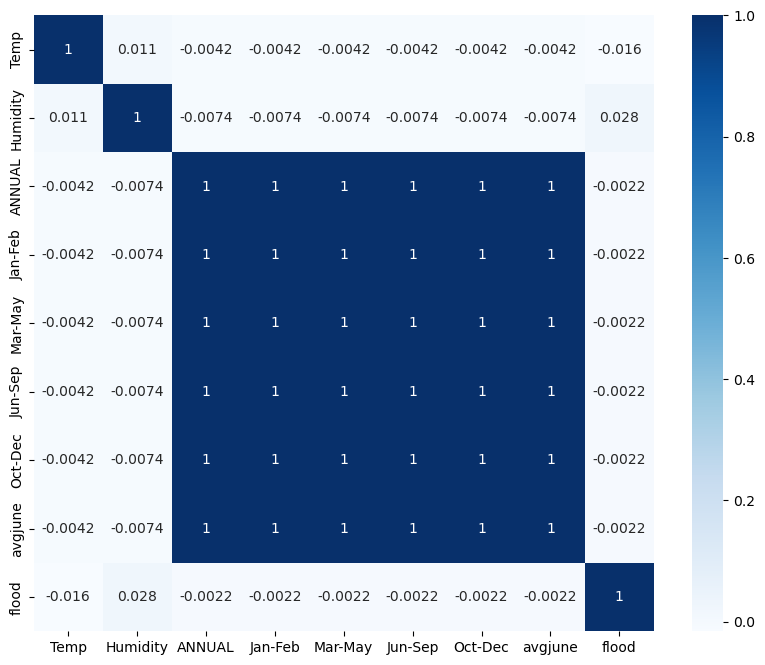

In [61]:
plt.figure(figsize=(10,8))

sns.heatmap(dataset.corr(), annot=True, cmap="Blues")

plt.show()

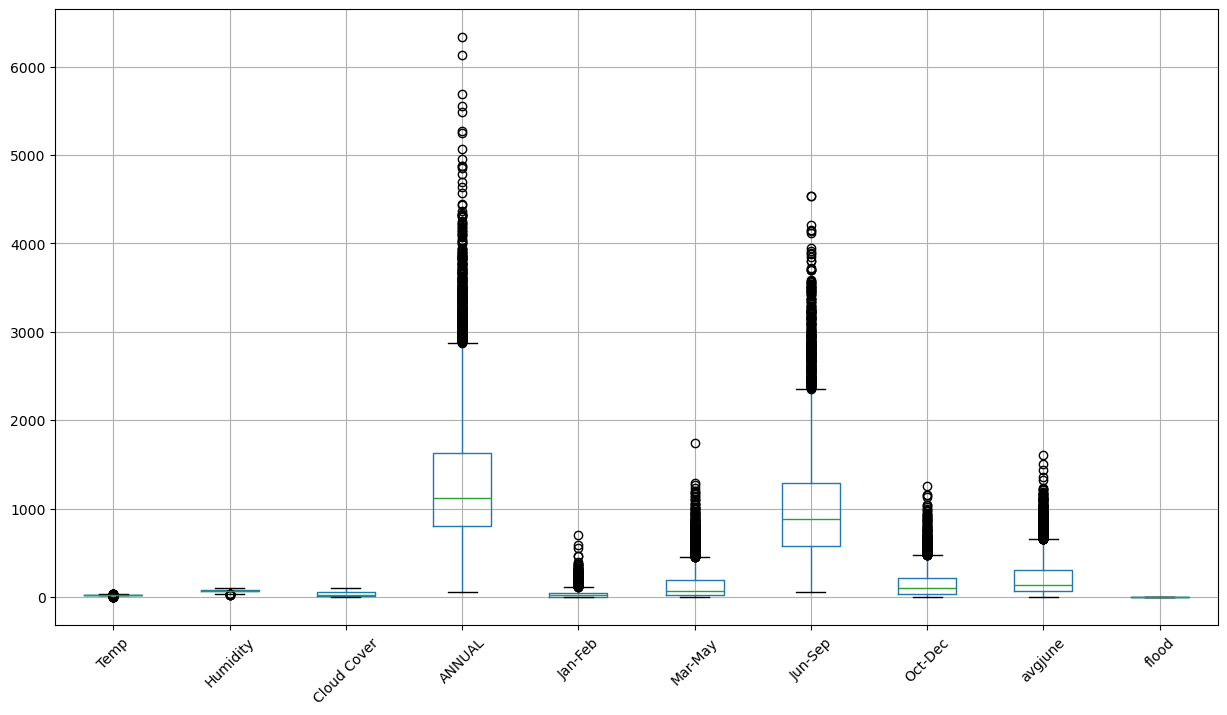

In [ ]:
plt.figure(figsize=(15,8))

dataset.boxplot()

plt.xticks(rotation=45)

plt.show()

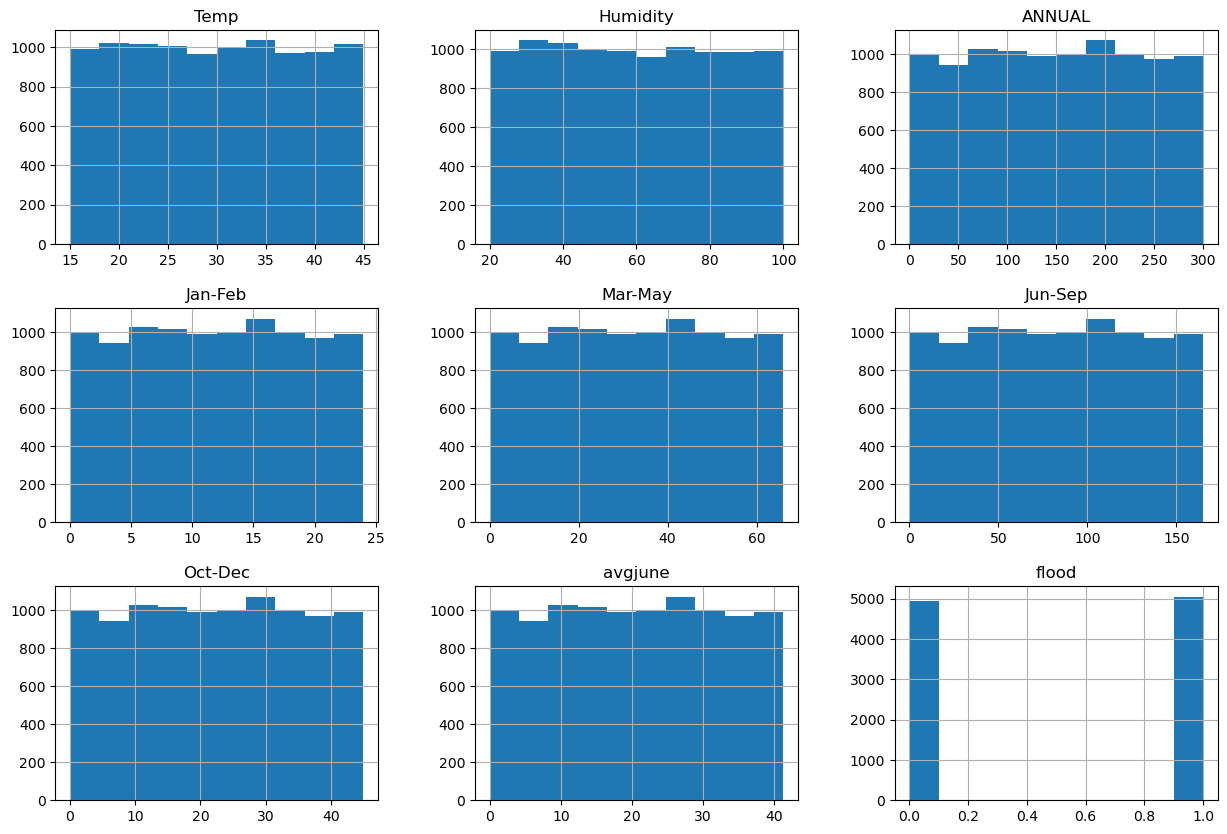

In [62]:
dataset.hist(figsize=(15,10))

plt.show()

In [64]:
X = dataset.drop("flood", axis=1)

y = dataset["flood"]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (8000, 8)
Testing Shape : (2000, 8)


In [67]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_train.value_counts())
print(y_train_balanced.value_counts())

flood
1    4046
0    3954
Name: count, dtype: int64
flood
0    4046
1    4046
Name: count, dtype: int64


In [69]:
#DecisionTree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_balanced, y_train_balanced)

dt_pred = dt.predict(X_test_scaled)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.503


In [70]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_balanced, y_train_balanced)

rf_pred = rf.predict(X_test_scaled)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.4975


In [71]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_balanced, y_train_balanced)

knn_pred = knn.predict(X_test_scaled)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.506


In [72]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

xgb.fit(X_train_balanced, y_train_balanced)

xgb_pred = xgb.predict(X_test_scaled)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.5075


In [73]:
accuracy = {
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

for model, score in accuracy.items():
    print(f"{model}: {score:.4f}")

Decision Tree: 0.5030
Random Forest: 0.4975
KNN: 0.5060
XGBoost: 0.5075


In [74]:
print(confusion_matrix(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

[[499 490]
 [495 516]]
              precision    recall  f1-score   support

           0       0.50      0.50      0.50       989
           1       0.51      0.51      0.51      1011

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



In [75]:
import os
import joblib

os.makedirs("Models", exist_ok=True)

joblib.dump(xgb, "Models/floods.save")
joblib.dump(scaler, "Models/transform.save")

['Models/transform.save']

In [79]:
import hashlib

with open("Models/floods.save", "rb") as f:
    print("Notebook model MD5:", hashlib.md5(f.read()).hexdigest())

Notebook model MD5: efb7ba1ce45391486d1205b8e67c140d


In [78]:
print("Flood records\n \n", dataset[dataset["flood"] == 1].head(10))
print("Non-Flood records\n \n", dataset[dataset["flood"] == 0].head(10))

Flood records
 
          Temp   Humidity      ANNUAL    Jan-Feb    Mar-May     Jun-Sep  \
0   34.144337  43.912963  218.999493  17.519959  48.179889  120.449721   
2   43.934956  30.108738  103.991908   8.319353  22.878220   57.195550   
5   36.006300  39.380945  221.571312  17.725705  48.745689  121.864221   
6   39.766935  40.436802  288.362370  23.068990  63.439721  158.599304   
7   27.209131  56.457308   34.964006   2.797121   7.692081   19.230203   
10  28.064283  92.583714  124.343018   9.947441  27.355464   68.388660   
11  41.868814  64.251178    9.858818   0.788705   2.168940    5.422350   
15  39.601734  54.229959  269.875565  21.590045  59.372624  148.431561   
17  18.082377  48.357780  291.654890  23.332391  64.164076  160.410190   
18  34.841212  20.712469  179.721453  14.377716  39.538720   98.846799   

      Oct-Dec    avgjune  flood  
0   32.849924  30.112430      1  
2   15.598786  14.298887      1  
5   33.235697  30.466055      1  
6   43.254356  39.649826      1 